In [70]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget
from scipy.stats import zscore

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

sc.settings.verbosity = 3

In [2]:
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/processed.h5ad"
adata = sc.read_h5ad(fpath)
adata.X = adata.layers['log_norm'].copy()
rsc.get.anndata_to_GPU(adata) # move to GPU
adata

AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'batch_colors', 'bbknn_clusters_colors', 'harmony_clusters_colors', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'rank_genes_grou

# Cluster Analysis

[2025-04-22 12:31:19.887] [CUML] [debug] n_neighbors=15
[2025-04-22 12:31:19.887] [CUML] [debug] Calling knn graph run
[2025-04-22 12:31:19.887] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-04-22 12:31:20.041] [CUML] [debug] Done. Calling remove zeros


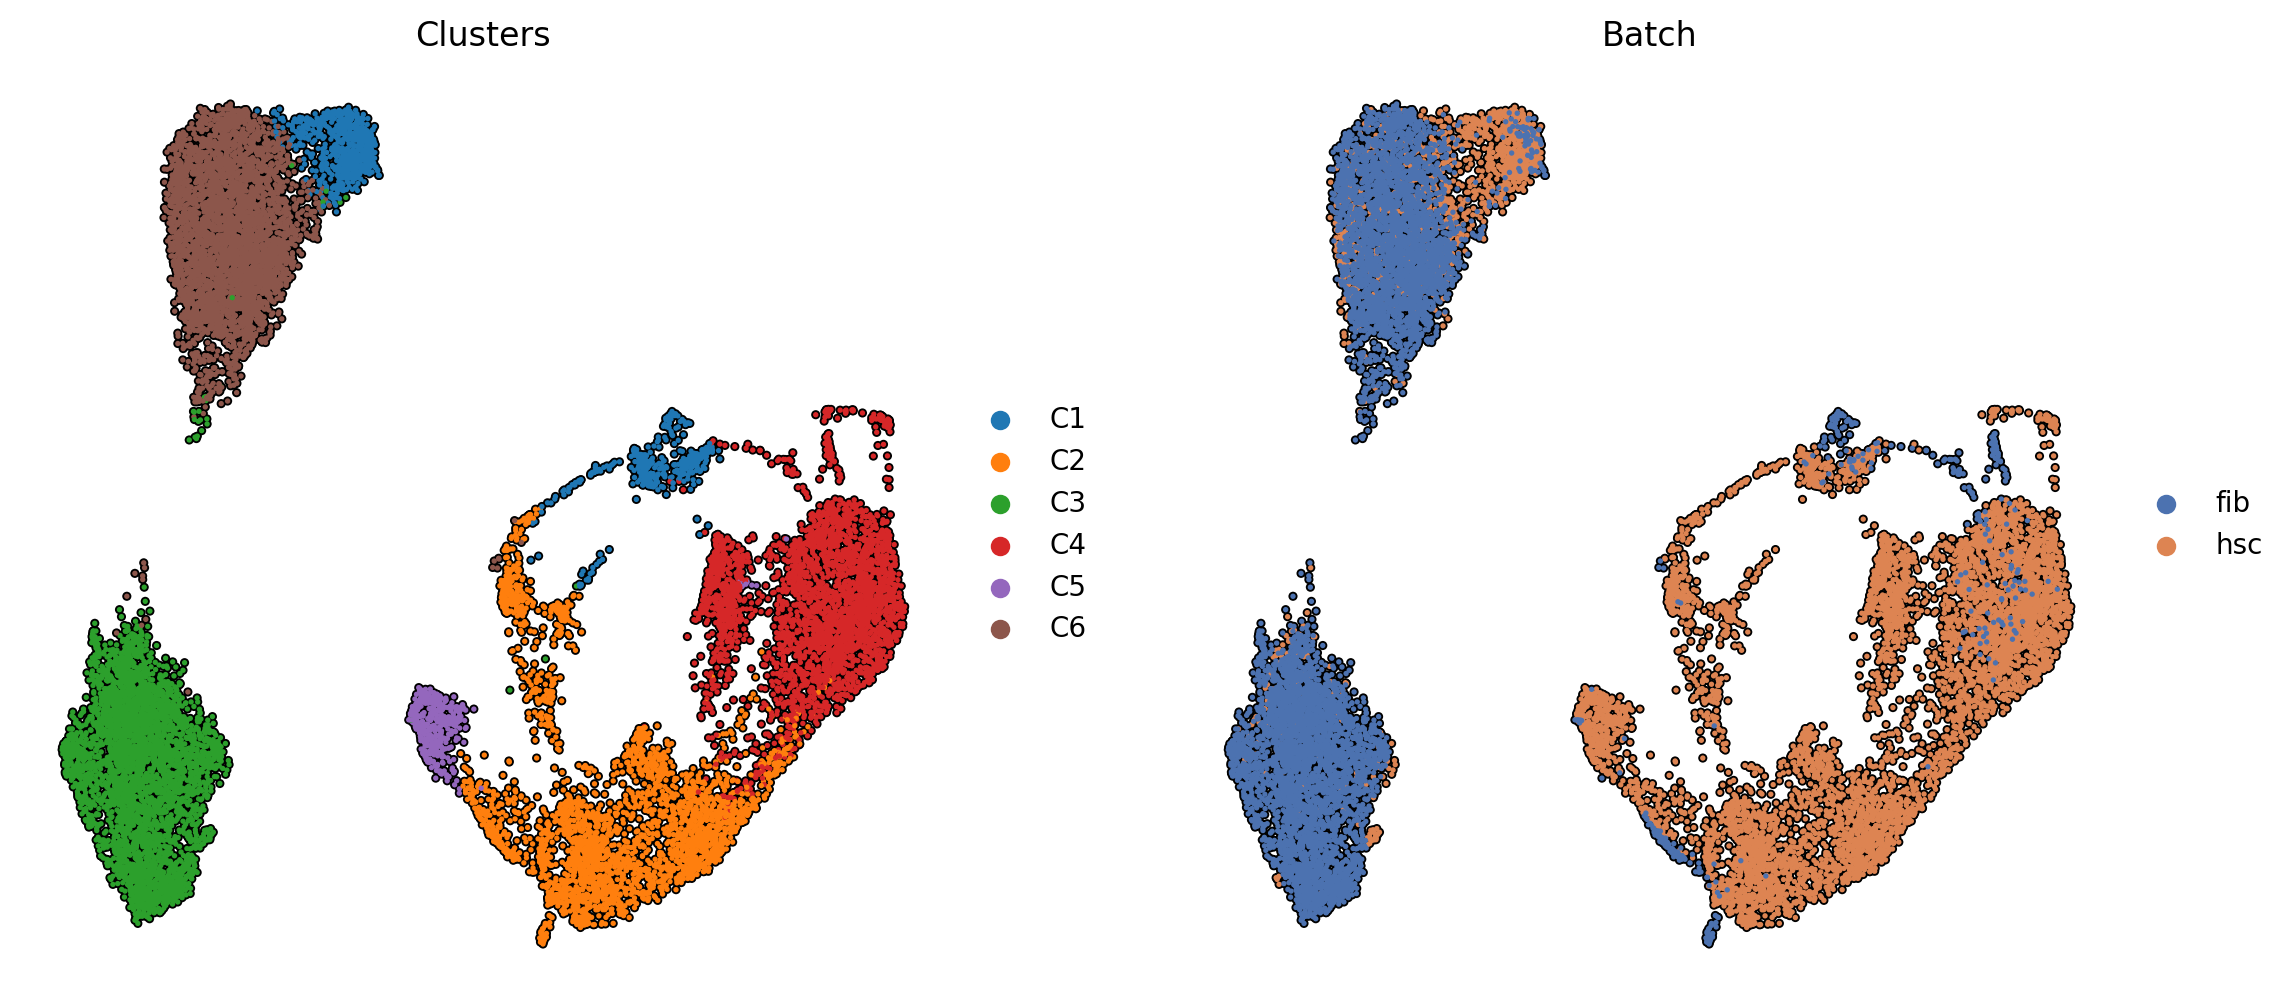

In [3]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 6

rsc.pp.neighbors(
    adata,
    # n_neighbors=20,
    use_rep='X_pca_harmony',
)
rsc.tl.leiden(adata, resolution=0.25)
adata.obs['cluster_str'] = adata.obs['leiden'].astype(int).apply(lambda x: f"C{x+1}")

sc.pl.umap(
    adata,
    ncols=2,
    color=['cluster_str', 'batch'],   
    size=15,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
    title=['Clusters', 'Batch'],
)

In [4]:
# break

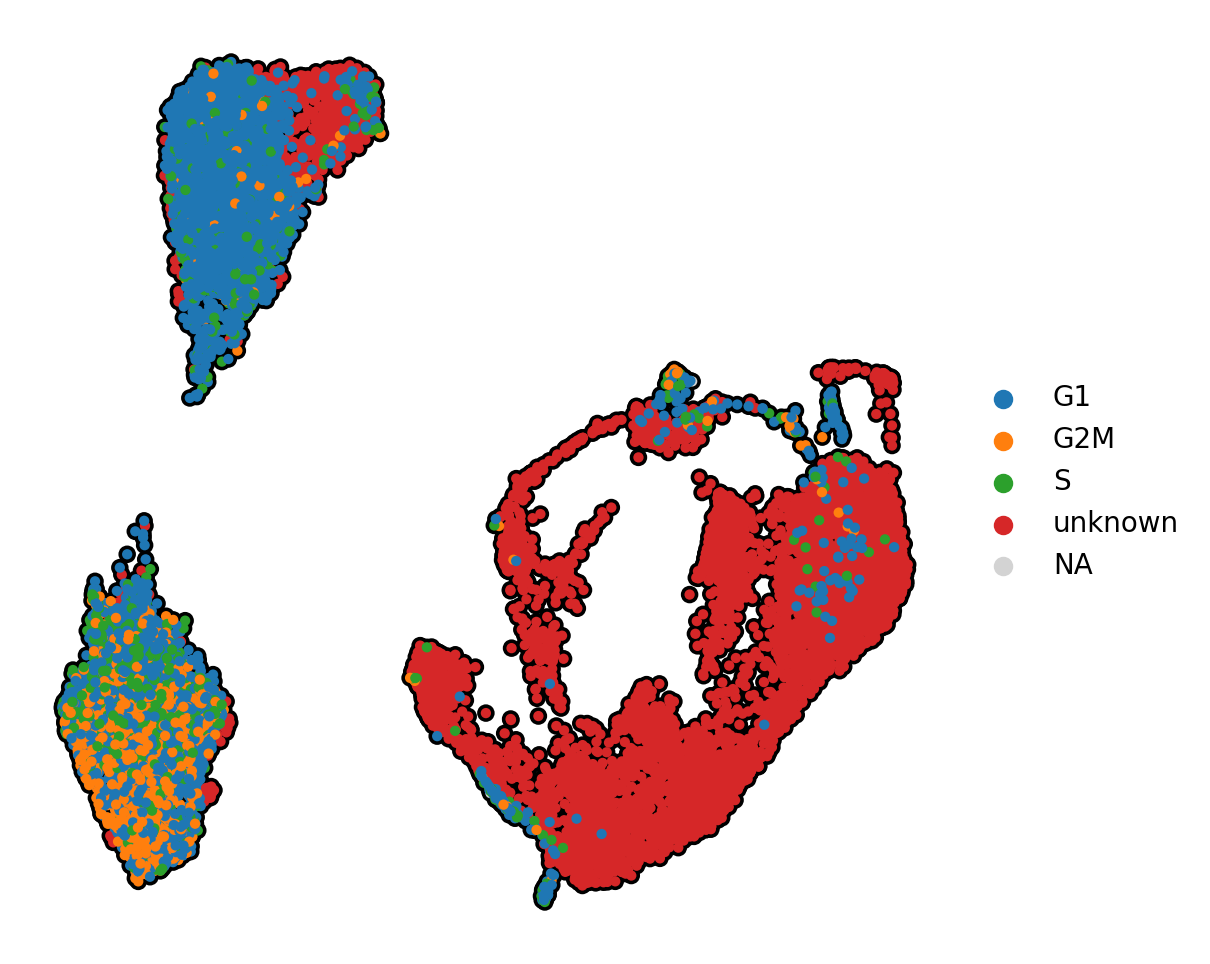

In [5]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 6

sc.pl.umap(
    adata,
    ncols=1,
    color='phase',
    size=55,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
    title="",
)

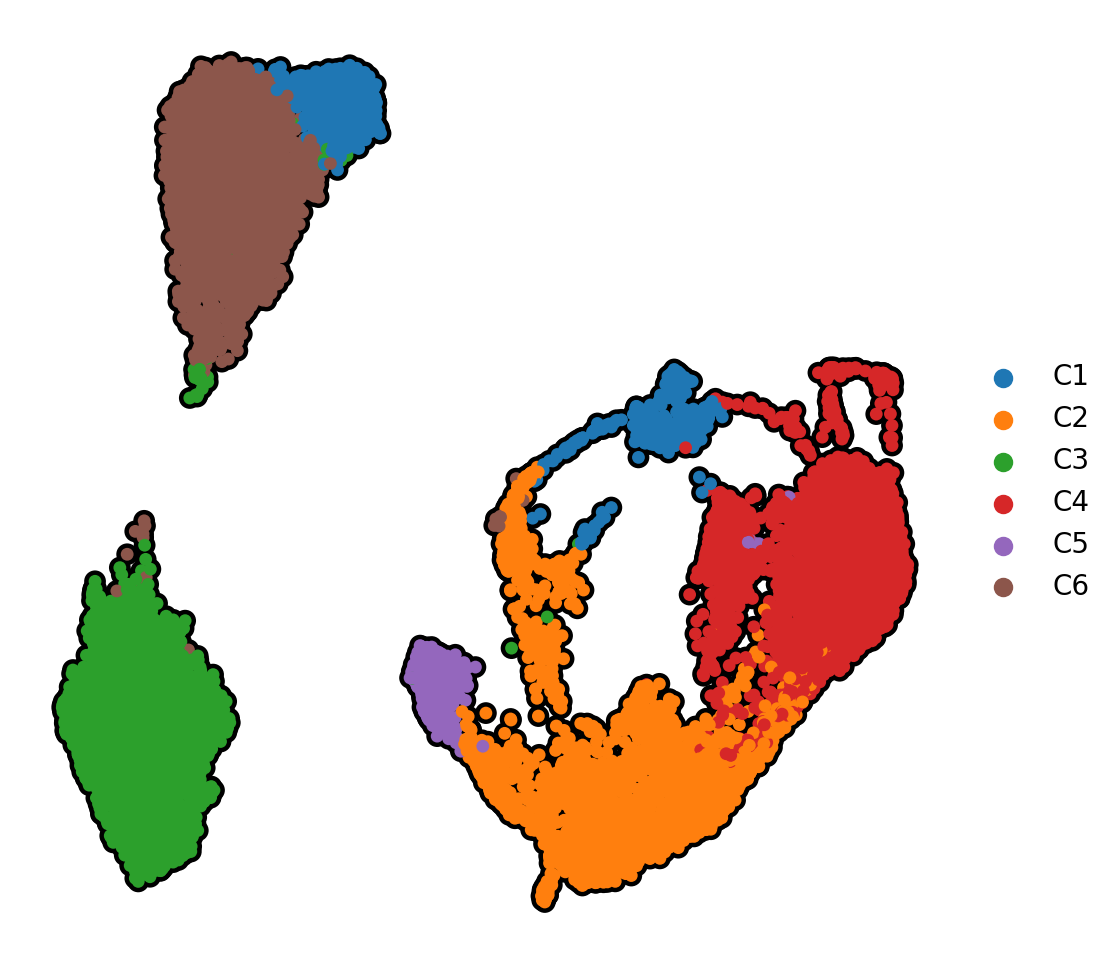

In [6]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 6

sc.pl.umap(
    adata,
    ncols=1,
    color='cluster_str',
    size=85,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
    # palette='Set1',
    title="",
)

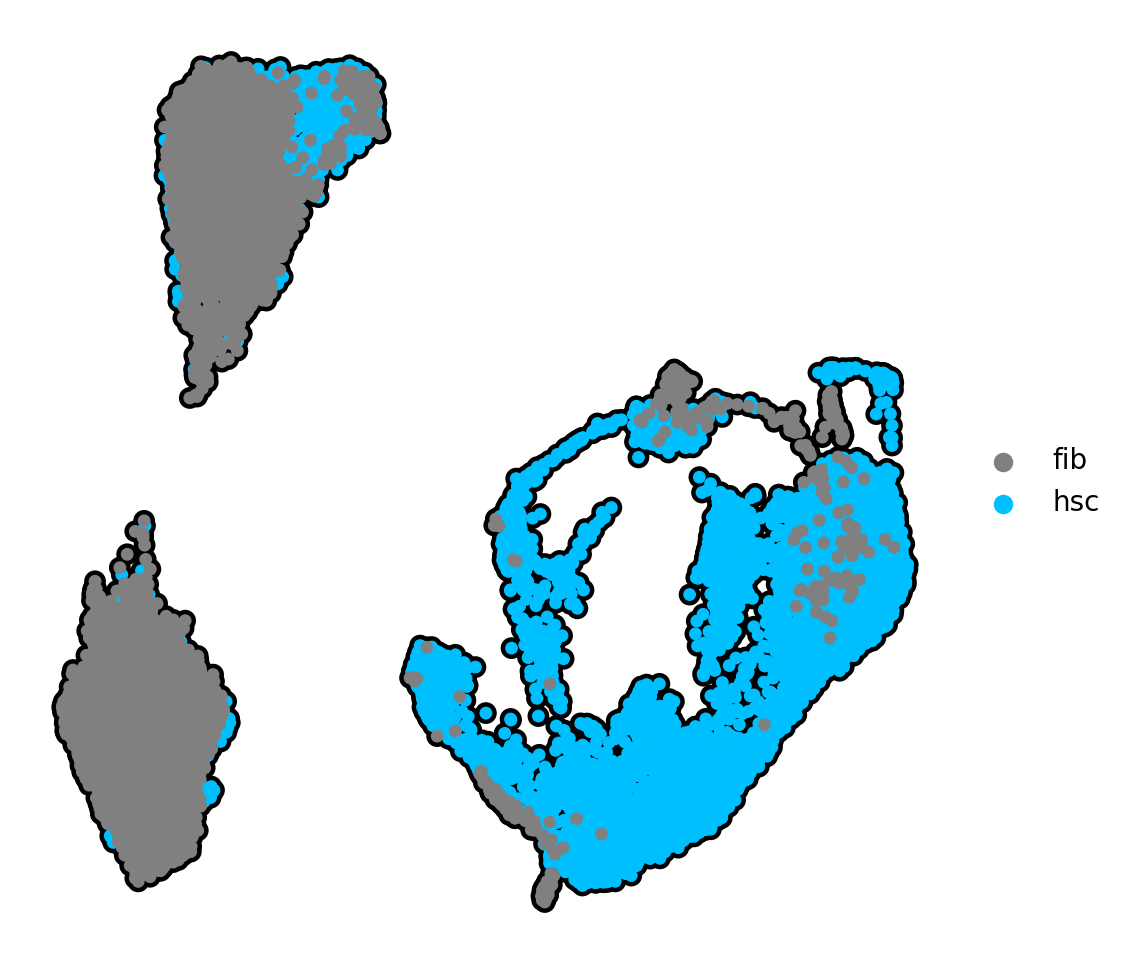

In [7]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 6

sc.pl.umap(
    adata,
    ncols=1,
    color='batch',
    size=85,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
    palette=['Grey', 'deepskyblue'],
    title="",
)

/tmp/ipykernel_2176946/1708216825.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


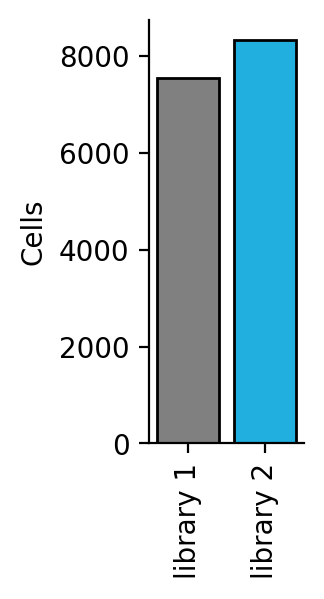

In [8]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 1, 2.75

sns.barplot(
    adata.obs['batch'].value_counts(),
    ec='k',
    palette=['Grey', 'deepskyblue'],
)

plt.xlabel("")
plt.ylabel("Cells")
plt.gca().set_xticklabels(['library 1', 'library 2'], rotation=90)
# plt.gca().tick_params()

sns.despine()

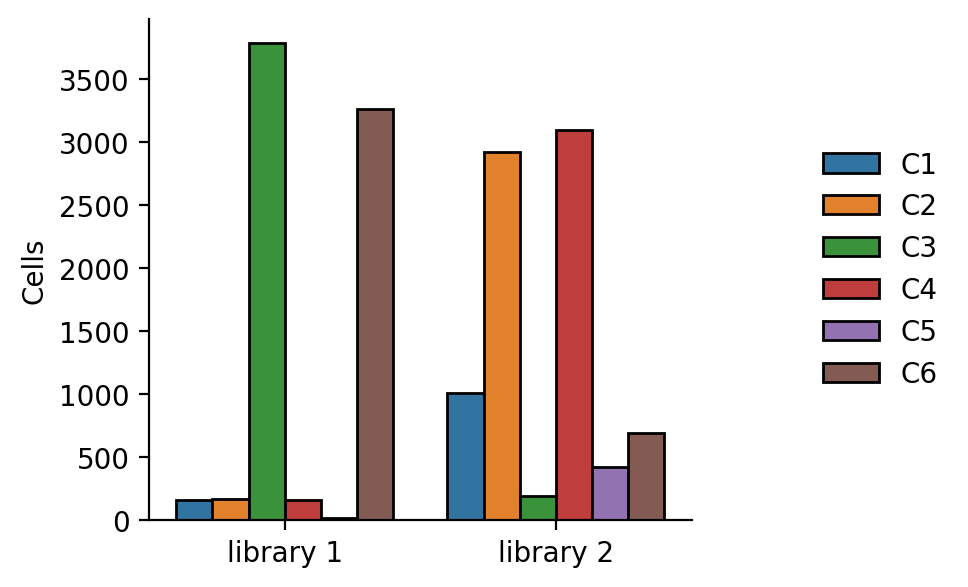

In [9]:
df = adata.obs[['batch', 'cluster_str']].value_counts().reset_index(name='count')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3.5, 3.25

sns.barplot(
    data=df,
    x='batch',
    y='count',
    hue='cluster_str',
    ec='k',
)

plt.xlabel("")
plt.ylabel("Cells")
plt.gca().set_xticklabels(['library 1', 'library 2'])
sns.move_legend(
    plt.gca(),
    loc='center right',
    title="",
    frameon=False,
    bbox_to_anchor=(1.5, 0.5),
)


sns.despine()

In [10]:
# Create a frequency table of 'batch' and 'cluster_str'
df = adata.obs[['batch', 'cluster_str']].value_counts().reset_index(name='count')

# Calculate percentage within each batch (dataset)
df['percentage'] = df.groupby('batch')['count'].transform(lambda x: 100 * x / x.sum())

# Optionally, round the percentage to one decimal place
df['percentage'] = df['percentage'].round(1)

# Sort by dataset ('batch') and then by count (descending order)
df = df.sort_values(by=['batch', 'cluster_str'], ascending=[True, True])

# Print the table without the default DataFrame index
print(df.to_latex(index=False))

\begin{tabular}{llrr}
\toprule
batch & cluster_str & count & percentage \\
\midrule
fib & C1 & 154 & 2.000000 \\
fib & C2 & 167 & 2.200000 \\
fib & C3 & 3791 & 50.300000 \\
fib & C4 & 155 & 2.100000 \\
fib & C5 & 9 & 0.100000 \\
fib & C6 & 3265 & 43.300000 \\
hsc & C1 & 1003 & 12.000000 \\
hsc & C2 & 2923 & 35.100000 \\
hsc & C3 & 191 & 2.300000 \\
hsc & C4 & 3100 & 37.200000 \\
hsc & C5 & 420 & 5.000000 \\
hsc & C6 & 689 & 8.300000 \\
\bottomrule
\end{tabular}



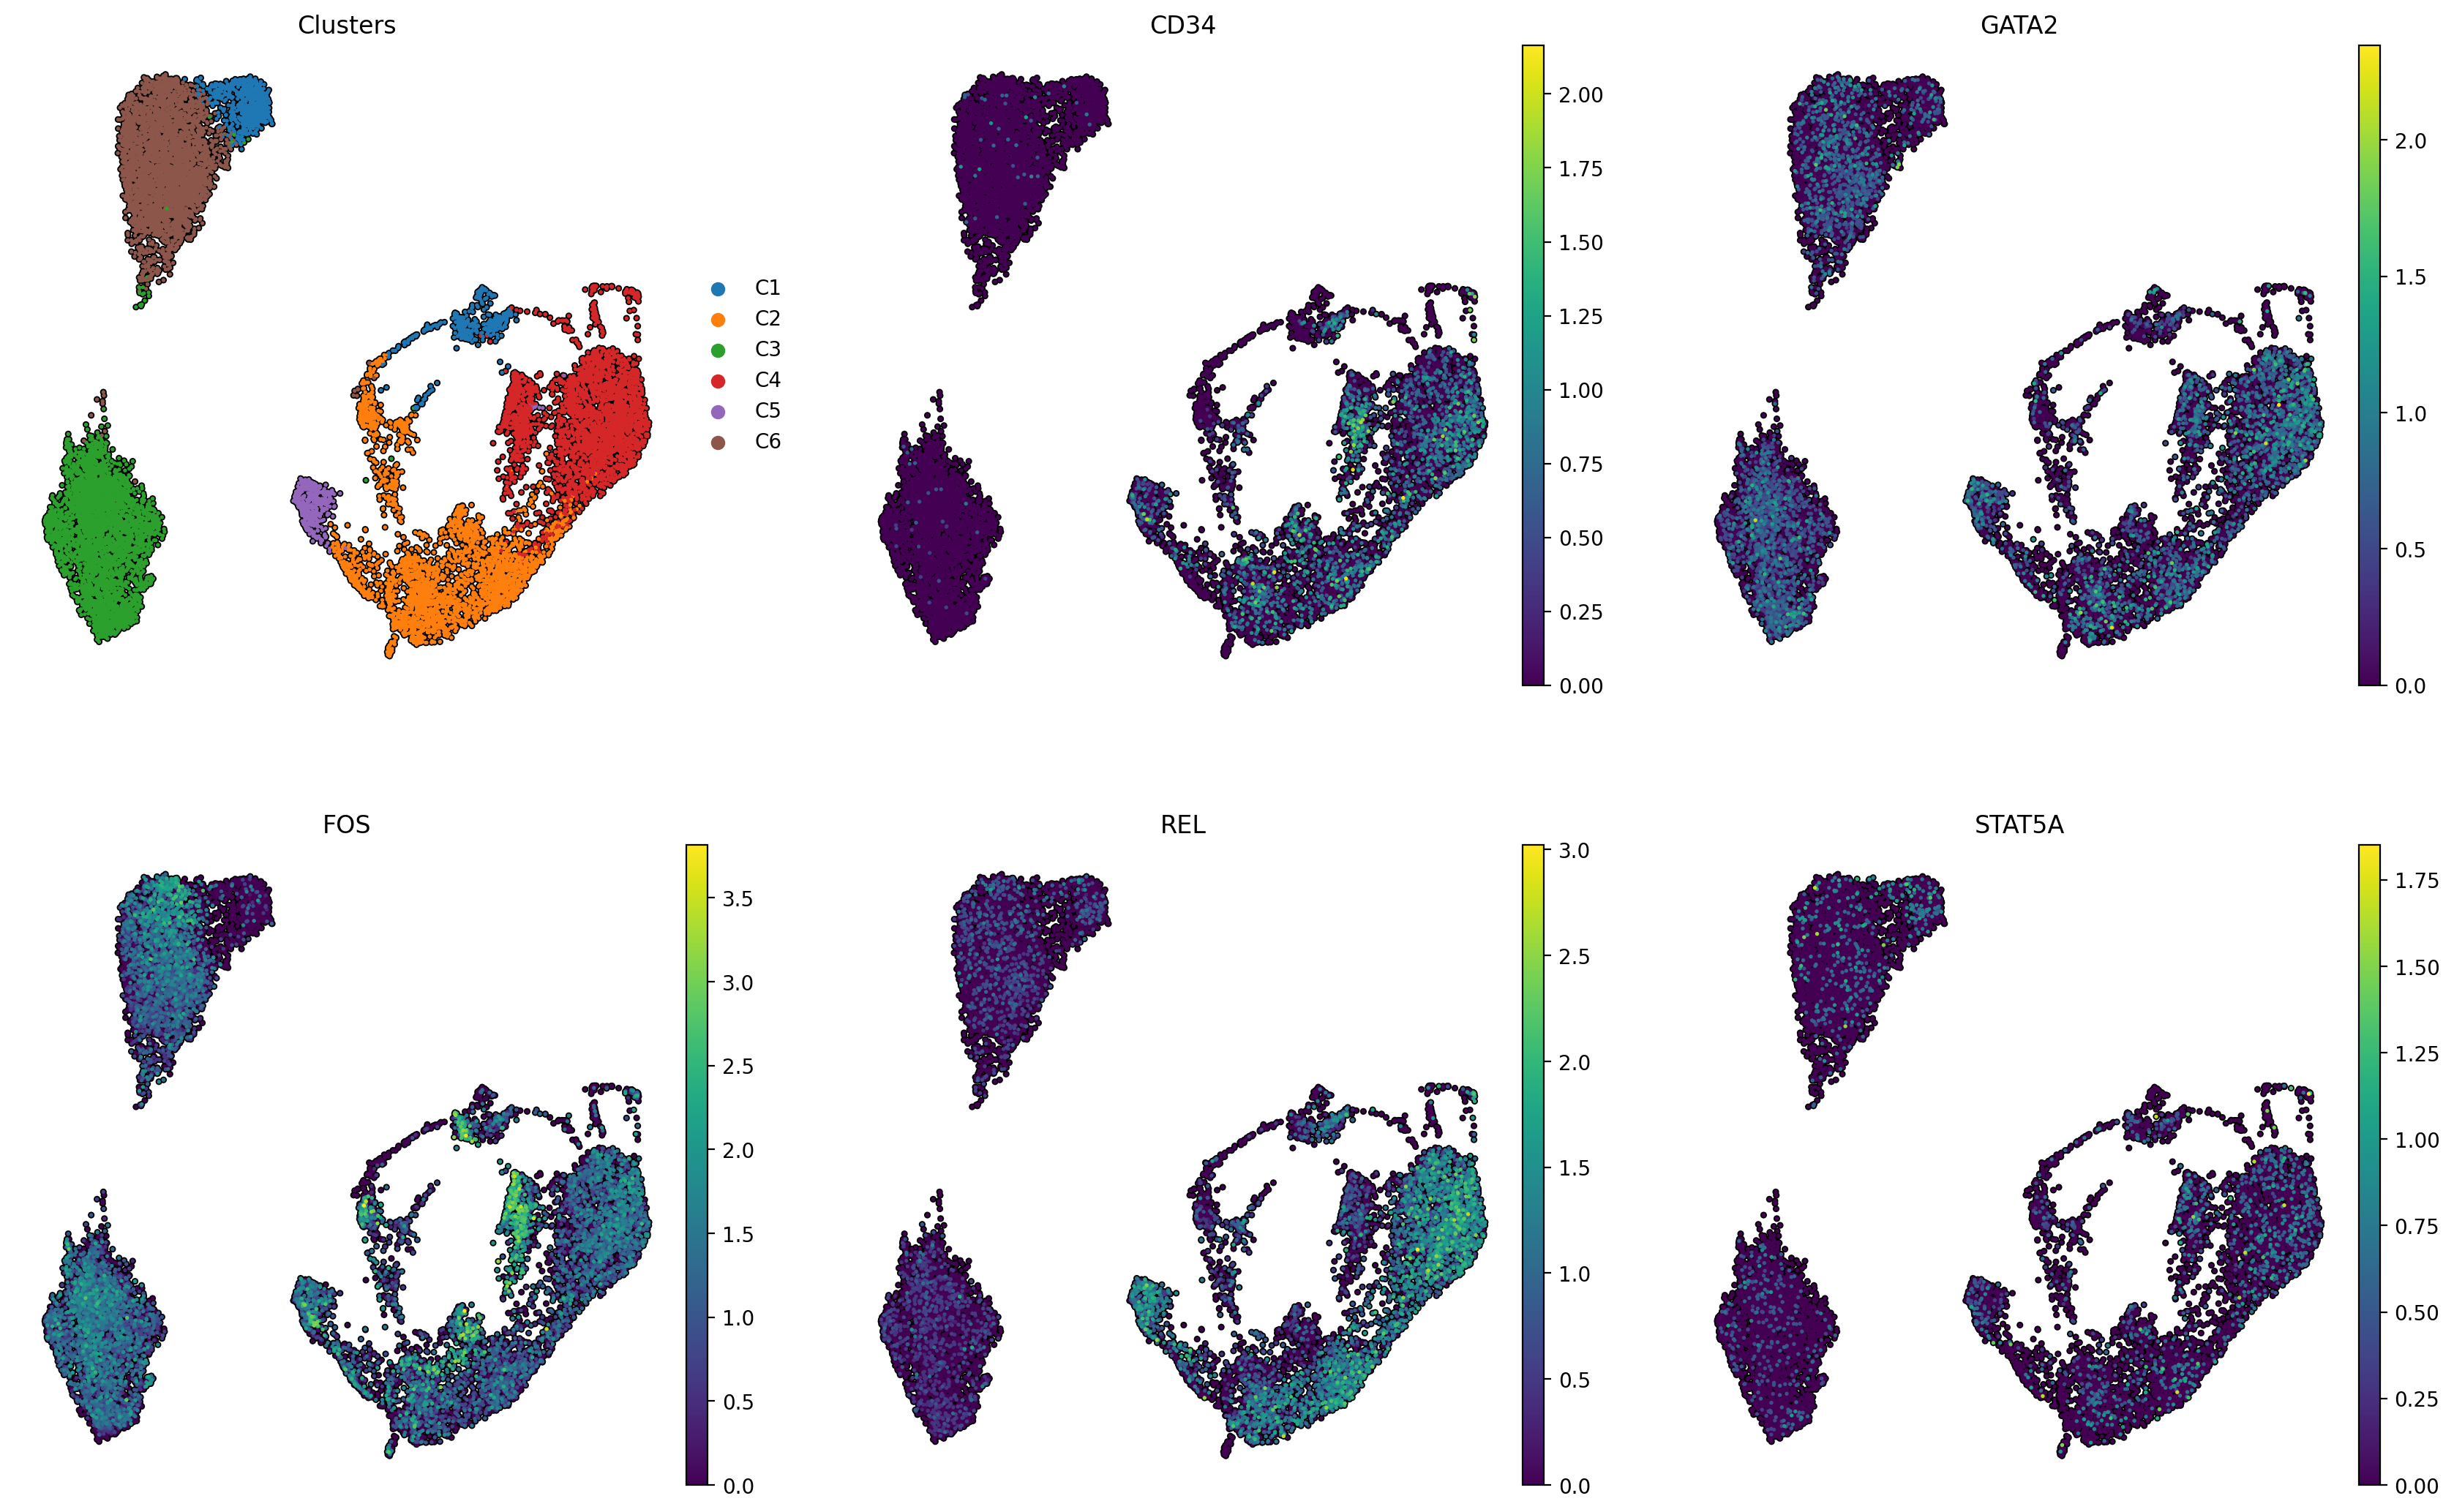

In [11]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 6

colors = [
    "cluster_str", 'CD34', 'GATA2', 'FOS', 'REL', "STAT5A",
]

titles = [
    'Clusters', 'CD34', 'GATA2', 'FOS', 'REL', "STAT5A",
]

sc.pl.umap(
    adata,
    ncols=3,
    color=colors,   
    size=15,
    add_outline=True,
    outline_color=('k', 'k'),
    layer='log_norm',
    alpha=1,
    frameon=False,
    title=titles,
)

In [12]:
# ?sc.pl.umap

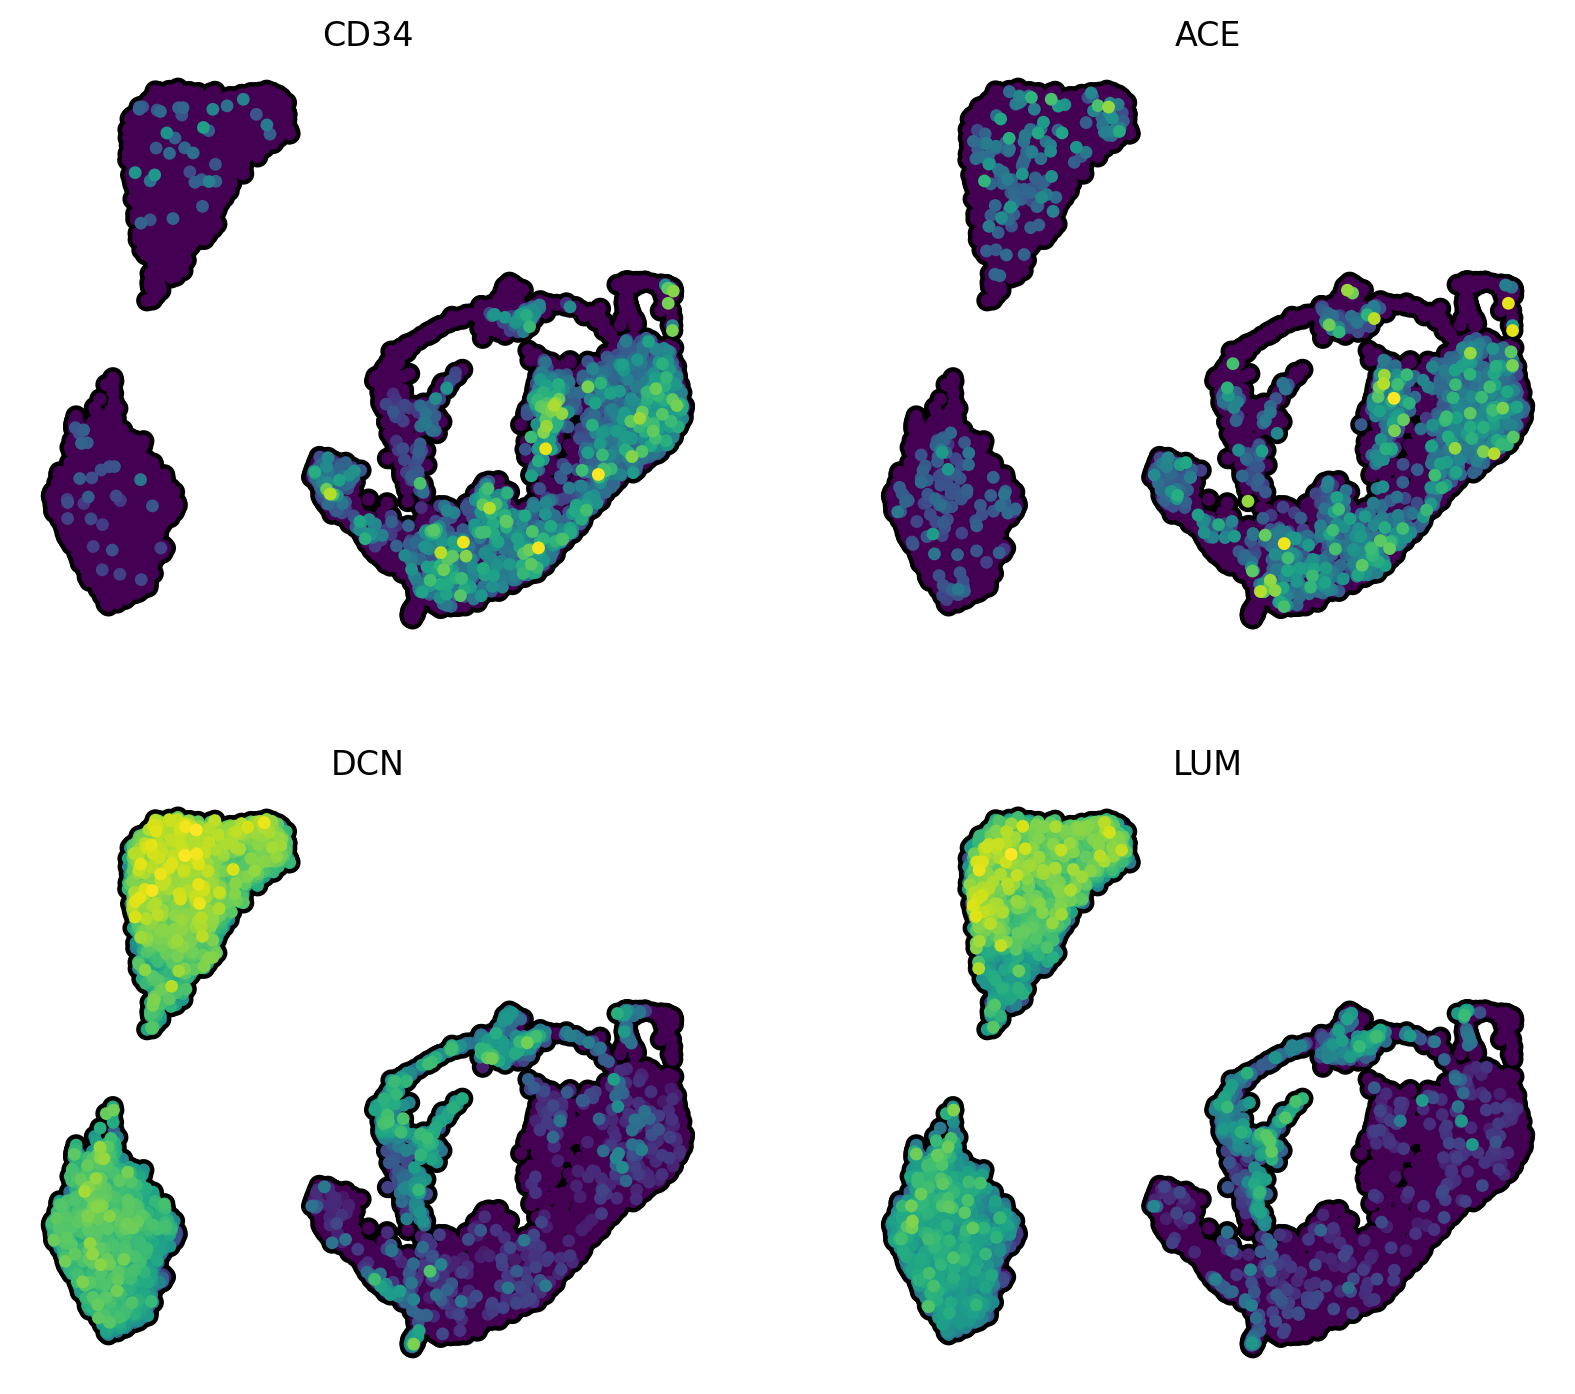

In [13]:

query = [
    'CD34', 'ACE',  'DCN', 'LUM',
]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    ncols=2,
    color=query,   
    size=85,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    cmap='viridis',
    layer='log_norm',
    frameon=False,
    colorbar_loc=None,
)


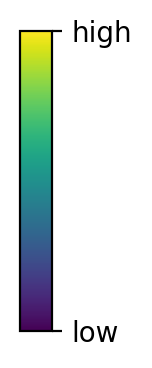

In [14]:
def make_colorbar(cmap='viridis', 
                  width=0.2,
                  height=2.5, 
                  title='', 
                  orientation='vertical', 
                  tick_labels=['low', 'high']):
    """
    Creates and displays a standalone colorbar using Matplotlib.

    Args:
        cmap (str or matplotlib.colors.Colormap): The colormap to use for the colorbar.
        width (float): The width of the colorbar figure in inches.
        height (float): The height of the colorbar figure in inches.
        title (str): The title to display above or next to the colorbar.
        orientation (str): The orientation of the colorbar ('vertical' or 'horizontal').
        tick_labels (list of str): The labels to display at each tick on the colorbar.

    Returns:
        None: This function displays the colorbar directly using Matplotlib.

    Raises:
        ValueError: If the `orientation` is not 'vertical' or 'horizontal'.
    """
    
    a = np.array([[0, 1]])  # Dummy data for the image
    plt.figure(figsize=(width, height))
    img = plt.imshow(a, cmap=cmap)
    plt.gca().set_visible(False)  # Hide the axes of the image
    cax = plt.axes([0.1, 0.2, 0.8, 0.6])  # Define the colorbar position

    ticks = np.linspace(0, 1, len(tick_labels)) 
    cbar = plt.colorbar(
        orientation=orientation,
        cax=cax,
        label=title,
        ticks=ticks
    )

    if orientation == 'vertical':
        cbar.ax.set_yticklabels(tick_labels)
    elif orientation == 'horizontal':
        cbar.ax.set_xticklabels(tick_labels)

make_colorbar()

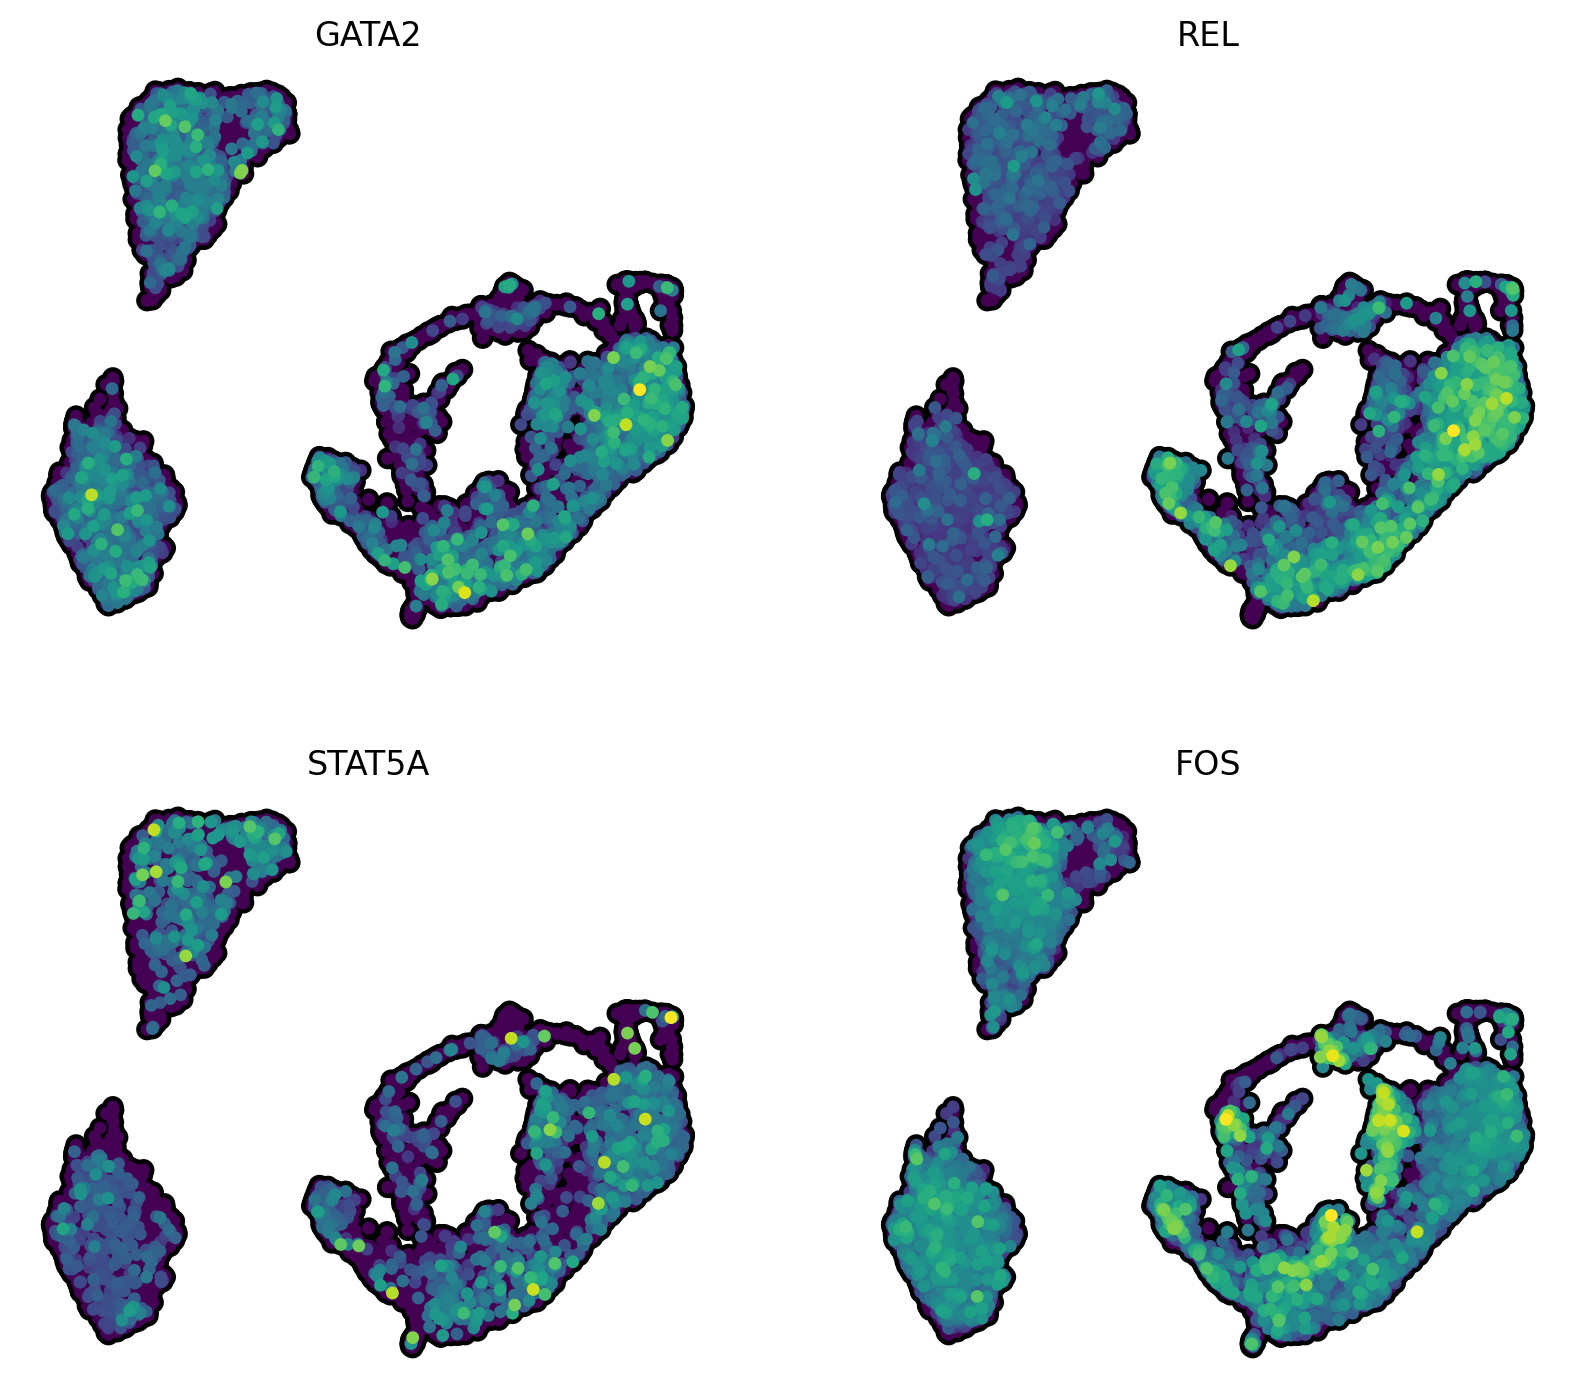

In [15]:

query = [
    "GATA2", "REL", "STAT5A", "FOS",
]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    ncols=2,
    color=query,   
    size=85,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    cmap='viridis',
    layer='log_norm',
    frameon=False,
    colorbar_loc=None,
)


In [16]:
# break

# Differential Expression on Groups

In [17]:
adata.obs['group'] = np.where(adata.obs['cluster_str'].isin(['C2', 'C4']), 'reprogramming', 'control')

sc.tl.rank_genes_groups(
    adata, 
    groupby='group',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    pval_cutoff=0.01,
)

deg.head()

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:01)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,control,DCN,97.840111,5.799534,0.0,0.0,0.951901,0.138219
1,control,IFI6,97.625465,5.456913,0.0,0.0,0.956207,0.449330
2,control,THBS1,95.038811,5.309133,0.0,0.0,0.948435,0.167376
3,control,LY6E,93.927803,2.829268,0.0,0.0,0.978786,0.707013
4,control,LUM,93.351280,5.170661,0.0,0.0,0.924701,0.106541


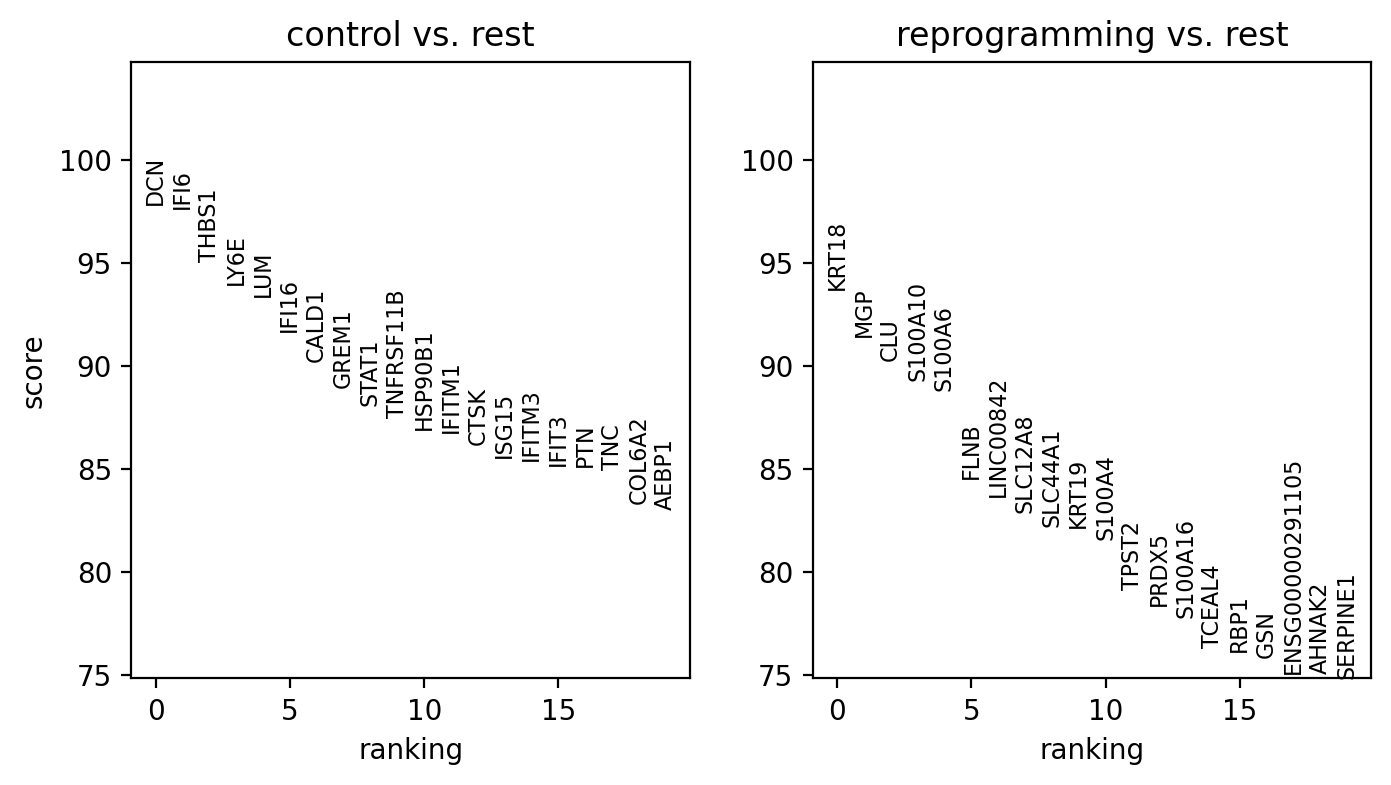

In [18]:
sc.pl.rank_genes_groups(adata)

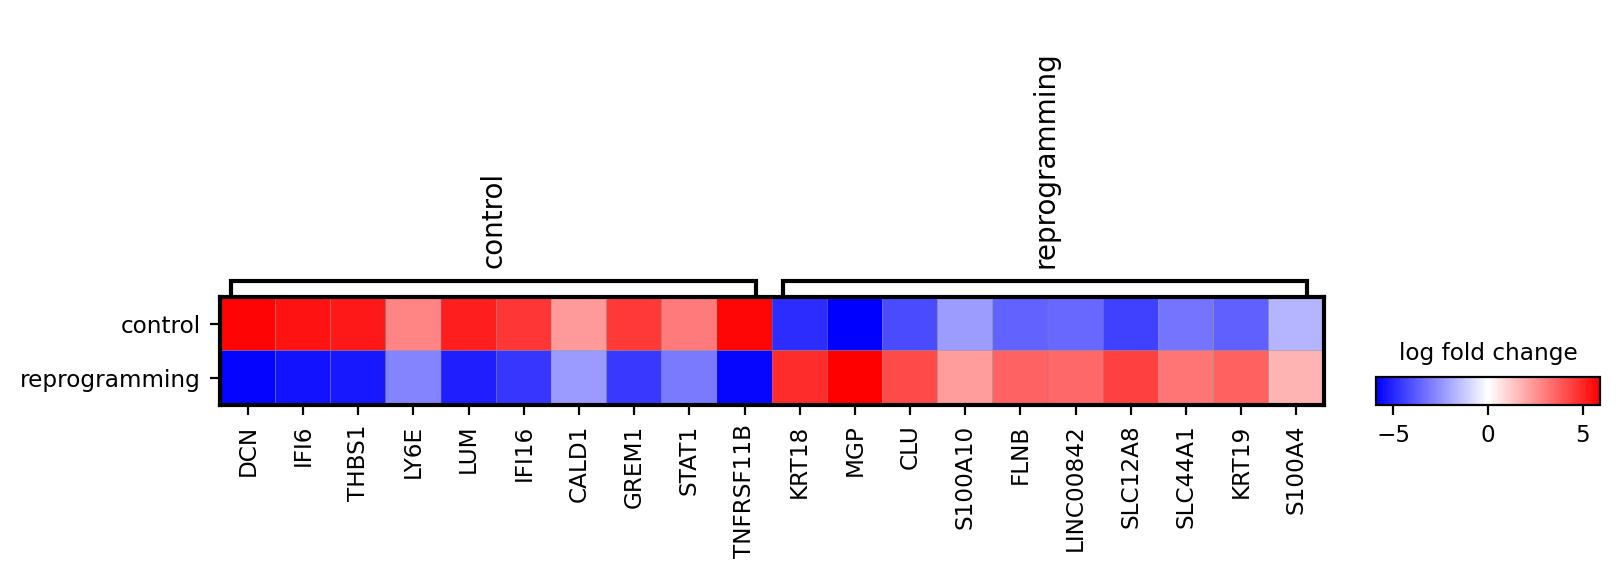

In [19]:
sc.pl.rank_genes_groups_matrixplot(
    adata,
    values_to_plot="logfoldchanges",
    cmap='bwr',
    # vmin=-4,
    # vmax=4,
    min_logfoldchange=1.5,
    colorbar_title='log fold change',
)

sig.shape=(10, 8)
        group     names    scores  logfoldchanges  pvals  pvals_adj  pct_nz_group  pct_nz_reference
      control       PTN 85.100426        6.089034    0.0        0.0      0.815900          0.034831
      control      BST2 54.647991        5.990397    0.0        0.0      0.523840          0.015918
      control THBS1-IT1 77.526871        5.933242    0.0        0.0      0.744907          0.027738
      control       DCN 97.840111        5.799534    0.0        0.0      0.951901          0.138219
      control TNFRSF11B 87.472084        5.761738    0.0        0.0      0.854757          0.087155
reprogramming       MGP 91.419373        5.901761    0.0        0.0      0.932072          0.202268
reprogramming      RBP1 76.094261        5.015174    0.0        0.0      0.755240          0.064692
reprogramming     KRT18 93.713448        4.859368    0.0        0.0      0.936328          0.373136
reprogramming   SLC12A8 82.885483        4.395498    0.0        0.0      0.841135 

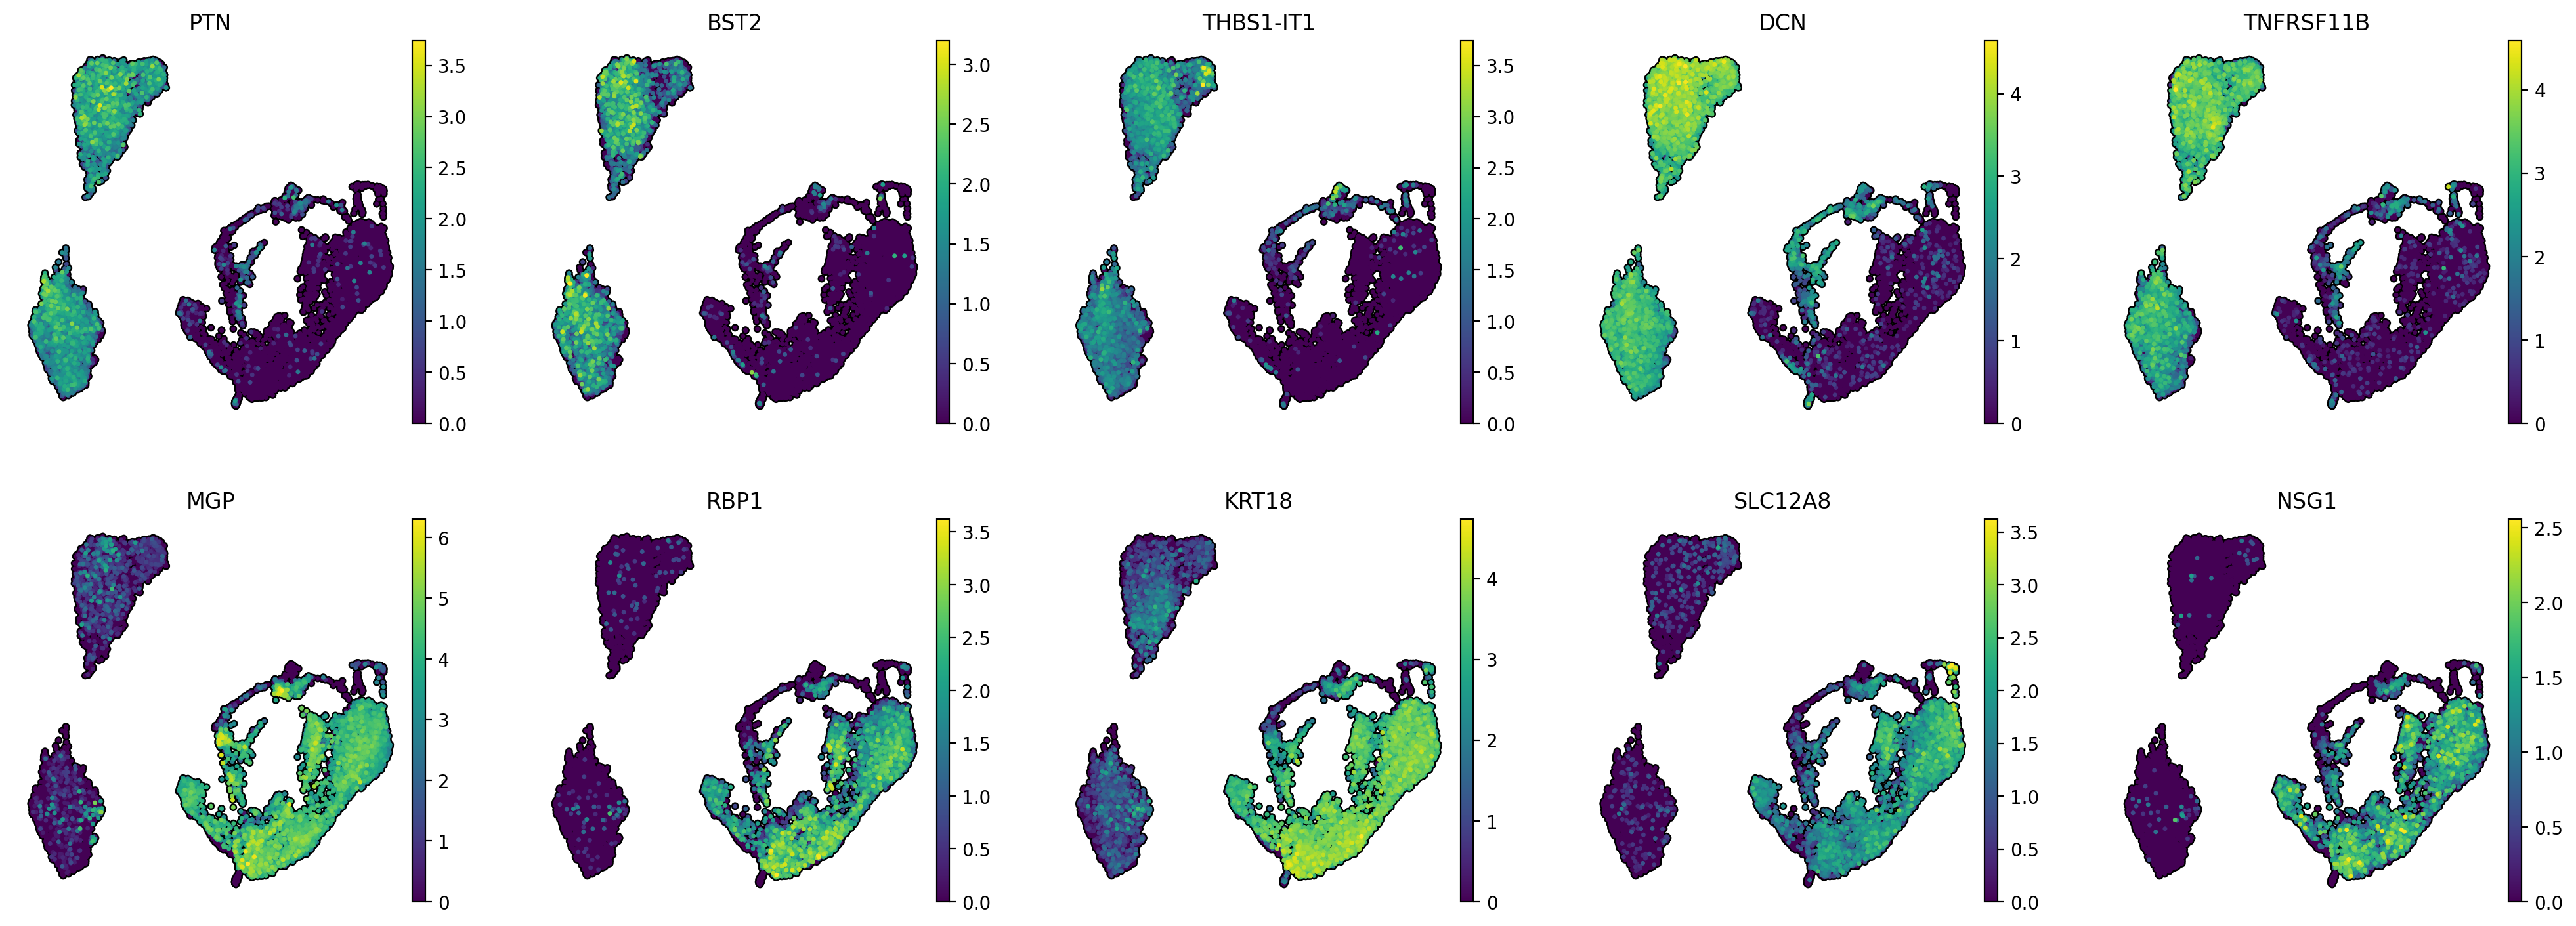

In [20]:
n_genes = 5
sig = deg.copy()
sig = sig[sig['pct_nz_group'] > 0.5]
sig = sig[sig['logfoldchanges'] > 1.5]
sig = sig.sort_values(['group', 'logfoldchanges'], ascending=[True, False])

sig = sig.groupby('group').head(n_genes)
print(f"{sig.shape=}")
print(sig.to_string(index=False))

sc.pl.umap(
    adata,
    ncols=n_genes,
    color=sig['names'],   
    size=25,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    cmap='viridis',
    layer='log_norm',
    frameon=False,
)


In [21]:
n_genes = 35
sig = deg.copy()
sig = sig[sig['pct_nz_group'] > 0.5]
sig = sig[sig['logfoldchanges'] > 1.5]
sig = sig[sig['group'] == 'reprogramming']
sig = sig.sort_values(['group', 'logfoldchanges'], ascending=[True, False])

sig = sig.head(n_genes)
print(sig['names'])
print(sig[['names', 'logfoldchanges', 'pct_nz_group', 'pct_nz_reference']].to_string(index=False))

9462                MGP
9476               RBP1
9461              KRT18
9468            SLC12A8
9495               NSG1
9518               MIAT
9463                CLU
9522               NEBL
9472              TPST2
9470              KRT19
9550                JUP
9559    ENSG00000276850
9501             PLAAT3
9466               FLNB
9479             AHNAK2
9499                CFB
9560            SLC35F3
9467          LINC00842
9511              PRSS3
9502              ABTB2
9517              MORC3
9530               GAS7
9469            SLC44A1
9526              ASAP2
9521             PRUNE2
9494              CENPT
9596             CHAF1B
9520              CLIC3
9544             SH3BP5
9531              FKBP5
9607               CA12
9498              HIPK2
9492    ENSG00000233461
9573    ENSG00000290032
9580              EFNA5
Name: names, dtype: object
          names  logfoldchanges  pct_nz_group  pct_nz_reference
            MGP        5.901761      0.932072          0.202268
     

# DEG All clusters

In [47]:
sc.tl.rank_genes_groups(
    adata, 
    groupby='cluster_str',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
)

deg.head()

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:06)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,C1,EXT1,47.250343,2.784685,0.0,0.0,0.993950,0.847927
1,C1,PRKG1,43.847168,2.702950,0.0,0.0,0.961106,0.645139
2,C1,MAML2,43.641708,2.684027,0.0,0.0,0.954192,0.550238
3,C1,LINC-PINT,41.496433,2.136824,0.0,0.0,0.954192,0.749422
4,C1,ATXN1,40.708336,2.319378,0.0,0.0,0.949870,0.694901


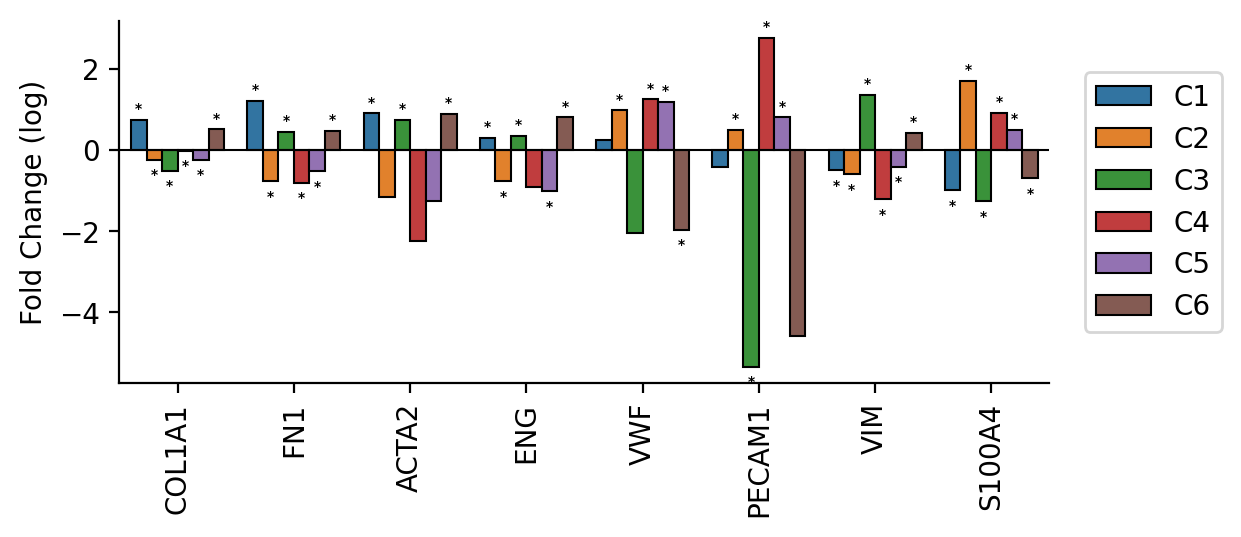

In [49]:
query = [
    # Fibroblast Markers
    "COL1A1", "VIM", "FN1", "ACTA2", "S100A4",
    # Hematopoietic Stem Cell Markers
    # "CD34", "THY1", "KIT", "PROM1", "SPINK2",
    # Endothelial Cell Markers
    "PECAM1", "CDH5", "VWF", "KDR", "ENG"
]

pdf = deg[deg['names'].isin(query)]

# Set up figure
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 2.35

ax = sns.barplot(
    data=pdf,
    x='names',
    y='logfoldchanges',
    hue='group',
    ec='k',
    lw=0.75,
)

# Add asterisks for significant values
for bar, (_, row) in zip(ax.patches, pdf.iterrows()):
    if row['pvals_adj'] < 0.05:
        height = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        offset = 0.1 if height >= 0 else -0.2
        ax.text(
            x, height + offset,
            "*",
            ha='center', va='bottom' if height >= 0 else 'top',
            fontsize=5, fontweight='bold'
        )

# Formatting
ax.tick_params(axis='x', rotation=90)
plt.ylabel("Fold Change (log)")
plt.xlabel("")
sns.despine()
plt.axhline(y=0, lw=0.75, c='k')

sns.move_legend(
    ax,
    loc='center right',
    title="",
    bbox_to_anchor=(1.2, 0.5)
)


   cluster variable     value    zscore
0       C4  ANGPTL4  0.638003  0.043266
50      C4  ANGPTL4  0.745697  0.498669
59      C4  ANGPTL4  0.663888  0.152724
74      C2  ANGPTL4  0.502616 -0.529243
84      C4  ANGPTL4  0.695757  0.287489


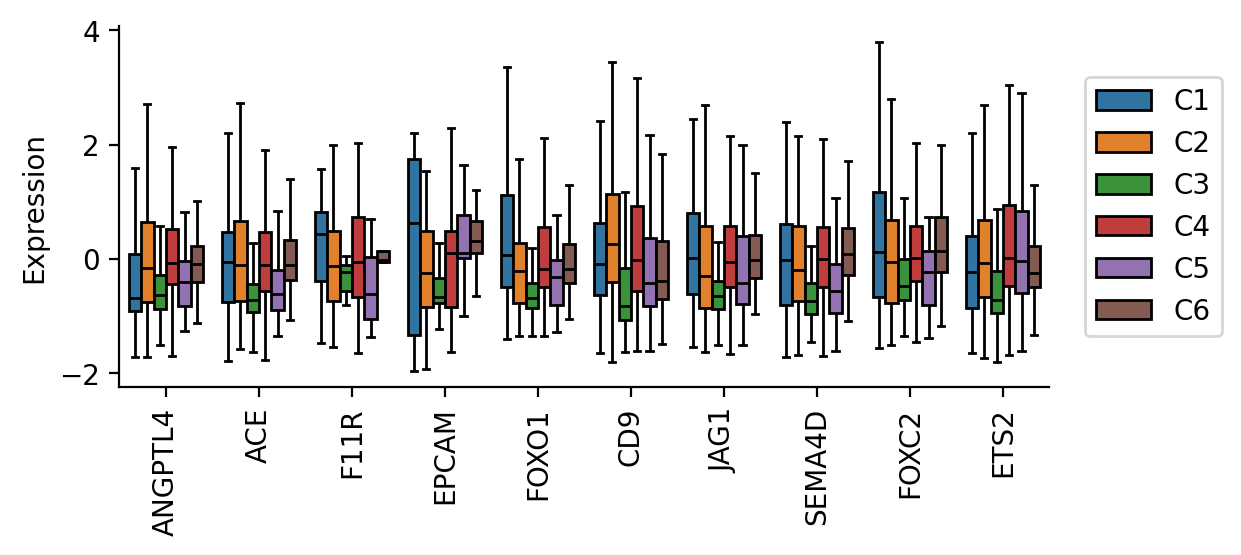

In [87]:
query = [
    # Transient or sequential expression during reprogramming
    "ANGPTL4",  # transient in CD49f+ cells
    "ACE",      # induced and maintained in CD34+CD49f+ cells

    # HSC/AGM precursor markers
    "F11R",     # AGM marker
    "EPCAM",    # AGM marker
    "SCL",      # HSC TF
    "FOXO1",    # HSC TF
    "CD9",      # HSC surface marker

    # Angiogenic program
    "JAG1",     # angiogenesis
    "SEMA4D",   # angiogenesis
    "FOXC2",    # angiogenesis
    "ETS2",     # angiogenesis
]

query = [x for x in query if x in adata.var_names]

rsc.get.anndata_to_CPU(adata) # moves `.X` to the CPU

df = adata[:, query].to_df()

df['cluster'] = adata.obs['cluster_str']
df = pd.melt(df, id_vars='cluster')
df = df[df['value'] > 0]
df['zscore'] = df.groupby(['variable'])['value'].transform(lambda x: zscore(x, ddof=0))

print(df.head().to_string())

sns.boxplot(
    data=df,
    x='variable',
    y='zscore',
    hue='cluster',
    showfliers=False,
    linecolor='k',
)

ax = plt.gca()

# Formatting
ax.tick_params(axis='x', rotation=90)
plt.ylabel("Expression")
plt.xlabel("")
sns.despine()

sns.move_legend(
    ax,
    loc='center right',
    title="",
    bbox_to_anchor=(1.2, 0.5)
)



In [23]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Pathway Genes

In [ ]:
def load_pathway(fpath):
    """
    Loads an Enrichr-like database file into a boolean DataFrame.

    Args:
        fpath (str): Path to the Enrichr-like database file.

    Returns:
        pandas.DataFrame: A boolean DataFrame where:
            - Index: Genes
            - Columns: Pathways
            - Values: True if the gene is in the pathway, False otherwise.
    """

    result = []
    with open(fpath,  encoding='utf-8') as f:
        for line in f:
            split_line = [x for x in line.strip().split('\t') if x]  # Remove empty strings directly

            row = {'label': split_line[0]}
            for gene in split_line[1:]:
                row[gene] = 1

            result.append(row)

    df = pd.DataFrame(result)
    df = df.fillna(0.0).set_index('label').astype(bool).T  # Chained operations for clarity

    return df

# PanglaoDB

In [ ]:
fpath = "../../resources/PanglaoDB_Augmented_2021.txt"
pdf = load_pathway(fpath)
cell_types = ['Hematopoietic Stem Cells', 'Endothelial Cells', 'Fibroblasts']

sig = deg.copy()
pct_nz_group = 0.15
logfoldchanges = 1.5
sig = sig[sig['pct_nz_group'] > pct_nz_group]
sig = sig[sig['logfoldchanges'] > logfoldchanges]

print("PanglaoDB Marker Genes")
print(f"\t Percent cell non-zero {pct_nz_group}")
print(f"\t Minimum log fold change {logfoldchanges}")

queries = {}
for ct in cell_types:
    marker_genes = list(pdf[pdf[ct]].index)
    query = sig[sig['names'].isin(marker_genes)]
    unique_genes = list(query['names'].unique())
    queries[ct] = query
    print(f"\n{ct} {len(marker_genes)} genes ({len(query)} DEG)")
    print(f"\t {query[query['group'] == 'control'].shape[0]} genes up in control")
    print(f"\t {query[query['group'] == 'reprogramming'].shape[0]} genes up in reprogramming")

        
print('done')

In [ ]:
n_genes = 3
for k, sig in queries.items():
    sig = sig.sort_values(['group', 'logfoldchanges'], ascending=[True, False])

    sig = sig.groupby('group').head(n_genes)
    print(f"{sig.shape=}")

    if sig.shape[0] == 0:
        continue

    sig['titles'] = sig['names'].astype(str) + " (lfc=" + sig['logfoldchanges'].round(1).astype(str) + ")"
    print(sig.to_string(index=False))
    
    axes = sc.pl.umap(
        adata,
        ncols=n_genes,
        color=sig['names'].tolist(), # Ensure it's a list if it's a Series
        size=25,
        add_outline=True,
        outline_color=('k', 'k'),
        alpha=1,
        cmap='viridis',
        layer='log_norm',
        frameon=False,
        title=sig['titles'].tolist(), # Ensure it's a list if it's a Series
        show=False 
    )
    fig = plt.gcf()
    fig.suptitle(f"{k}", fontsize=16) 
    plt.show()

# Other Endothelial Markers

In [ ]:
query = [
    "MAGI1", "PECAM1", "NDRG4", "NYAP1", "CMTM4", "SHROOM2", "GPRC5B", "NGEF",
]

sc.pl.umap(
    adata,
    ncols=4,
    color=query,   
    size=25,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    cmap='viridis',
    layer='log_norm',
    frameon=False,
)


# Tabula Sapiens

In [ ]:
fpath = "../../resources/Tabula_Sapiens.txt"
pdf = load_pathway(fpath)

search_types = {
    'hemat' : 'HSC',
    'fibroblast' : 'Fibroblast',
    'endoth' : 'Endothelial',
}

search_terms = {}
for search, label in search_types.items():
    search_terms[label] = [x for x in pdf.columns if search in x.lower()]

sig = deg.copy()
pct_nz_group = 0.15
logfoldchanges = 1.5
sig = sig[sig['pct_nz_group'] > pct_nz_group]
sig = sig[sig['logfoldchanges'] > logfoldchanges]

print("Tabula Sapiens Marker Genes")
print(f"\t Percent cell non-zero {pct_nz_group}")
print(f"\t Minimum log fold change {logfoldchanges}")

queries = {}
for label, columns in search_terms.items():
    marker_genes = list(pdf[pdf[columns].any(axis=1)].index)

    query = sig[sig['names'].isin(marker_genes)]
    unique_genes = list(query['names'].unique())
    queries[label] = query
    print(f"\n{label} {len(marker_genes)} genes ({len(query)} DEG)")
    print(f"\t {query[query['group'] == 'control'].shape[0]} genes up in control")
    print(f"\t {query[query['group'] == 'reprogramming'].shape[0]} genes up in reprogramming")
    # break

        
print('done')

In [ ]:
n_genes = 3
for k, sig in queries.items():
    if k == 'HSC':
        continue
    sig = sig.sort_values(['group', 'logfoldchanges'], ascending=[True, False])

    sig = sig.groupby('group').head(n_genes)
    print(f"{sig.shape=}")

    
    if sig.shape[0] == 0:
        continue

    sig['titles'] = sig['names'].astype(str) + " (lfc=" + sig['logfoldchanges'].round(1).astype(str) + ")"
    print(sig.to_string(index=False))
    
    axes = sc.pl.umap(
        adata,
        ncols=n_genes,
        color=sig['names'].tolist(), # Ensure it's a list if it's a Series
        size=25,
        add_outline=True,
        outline_color=('k', 'k'),
        alpha=1,
        cmap='viridis',
        layer='log_norm',
        frameon=False,
        title=sig['titles'].tolist(), # Ensure it's a list if it's a Series
        show=False 
    )
    fig = plt.gcf()
    fig.suptitle(f"{k}", fontsize=16) 
    plt.show()

# A new embedding